In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set1.csv"

In [3]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,63.7946,286.783685,440.511758,0.651024,0.735566,0.000454,0.205773,0.010205,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,63.9339,152.294798,403.001286,0.377902,0.731142,0.000461,0.225304,0.005911,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,63.9339,152.294798,403.001286,0.377902,0.731142,0.000461,0.225304,0.005911,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,63.9127,283.683549,479.803099,0.591250,0.732637,0.000459,0.189188,0.009251,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,63.9808,217.950740,519.883926,0.419230,0.732090,0.000465,0.174736,0.006552,0.0,No Anomaly


In [4]:
dataframe_anomaly = dataframe[["anomaly", "description"]]
dataframe.drop(columns=["anomaly", "description"], inplace=True)

## Helper Functions

In [5]:
def plot_pairplot(df, columns, title=None):
    """
    Plots a pairplot of the given dataframe with specified columns and hue.
    
    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
    """
    plt.figure(figsize=(12, 12), dpi=PLOT_DPI)
    g = sns.pairplot(
                        data = df, 
                        hue="description", 
                        hue_order=df["description"].value_counts().index, 
                        vars=columns, 
                        corner=True, 
                        plot_kws={"edgecolor": "black", "alpha": 0.6},
                        markers=["P", "X", "o", "v", "^", "<", ">", "h", "H", "D", "d", "s", "p", "8"],
    )
    sns.move_legend(g, "center right", ncol=1, title="description", frameon=True)
    g.fig.suptitle(title, y=1.02, weight="bold", fontsize=30) # Adjust y for vertical positioning

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    # plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/engineered_features/{title}.png", format="png")
    plt.show()

In [6]:
def get_fluctuation_data(dataframe, column_name):
    # 1. Deviation from a Rolling Mean (Common for time-series data)
    #    This highlights how much each point deviates from its local average.
    #    You"ll need to define a "window" size.

    # window_size = 5  # e.g., 5 data points
    # dataframe[f"{column_name}_Fluctuation_Rolling_Deviation"] = dataframe[column_name] - dataframe[column_name].rolling(window=window_size, center=True).mean()
    # Use .bfill() or .ffill() to handle NaNs at the start/end if center=True, or adjust windowing.
    # For simplicity, we"ll just show the calculation.

    # # 2. Rolling Standard Deviation (Measure of variability over a window)
    # dataframe[f"{column_name}_Fluctuation_Rolling_Std"] = dataframe[column_name].rolling(window=window_size).std()

    # # 3. Peak-to-Peak Fluctuation over a Rolling Window
    # #    This gives the max difference within a specified window.
    # dataframe[f"{column_name}_Fluctuation_Rolling_Peak_to_Peak"] = dataframe[column_name].rolling(window=window_size).apply(lambda x: x.max() - x.min(), raw=True)

    # # 4. Absolute Rate of Change (First Difference)
    # #    This shows how much pressure changes from one point to the next.
    # dataframe[f"{column_name}_Fluctuation_Rate_of_Change"] = dataframe[column_name].diff().abs() # Absolute change

    # # 5. Deviation from Overall Mean (If you"re looking at overall fluctuation)
    # dataframe[f"{column_name}_Fluctuation_Overall_Deviation"] = dataframe[column_name] - dataframe[column_name].mean()

    window_size = 5  # e.g., 5 data points
    # 6. Moving Average of Absolute Deviations (Another way to smooth fluctuations)
    #    This gives you a smoothed view of how much the pressure is typically deviating
    #    from a central tendency.
    dataframe[f"{column_name}_Fluctuation"] = (dataframe[column_name] - dataframe[column_name].rolling(window=window_size).mean()).abs().rolling(window=window_size).mean()

    return f"{column_name}_Fluctuation"

In [7]:
dataframe.columns

Index(['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
       'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS',
       'Electrical_Resistence', 'Flow_Resistance', 'Temperature_EbyF',
       'AccelerometerRMS', 'Specific_Power', 'Accelerometer_Balance',
       'Temperature_Difference', 'Hydraulic_Power', 'Electrical_Power',
       'Actual_Efficiency', 'Vibration_Intensity_Ratio',
       'AccelerometerRMS_pu_Pressure', 'Engine_Temperature_pu_Power',
       'Efficiency_Temperature_Difference_Ratio'],
      dtype='object')

<Figure size 1200x1200 with 0 Axes>

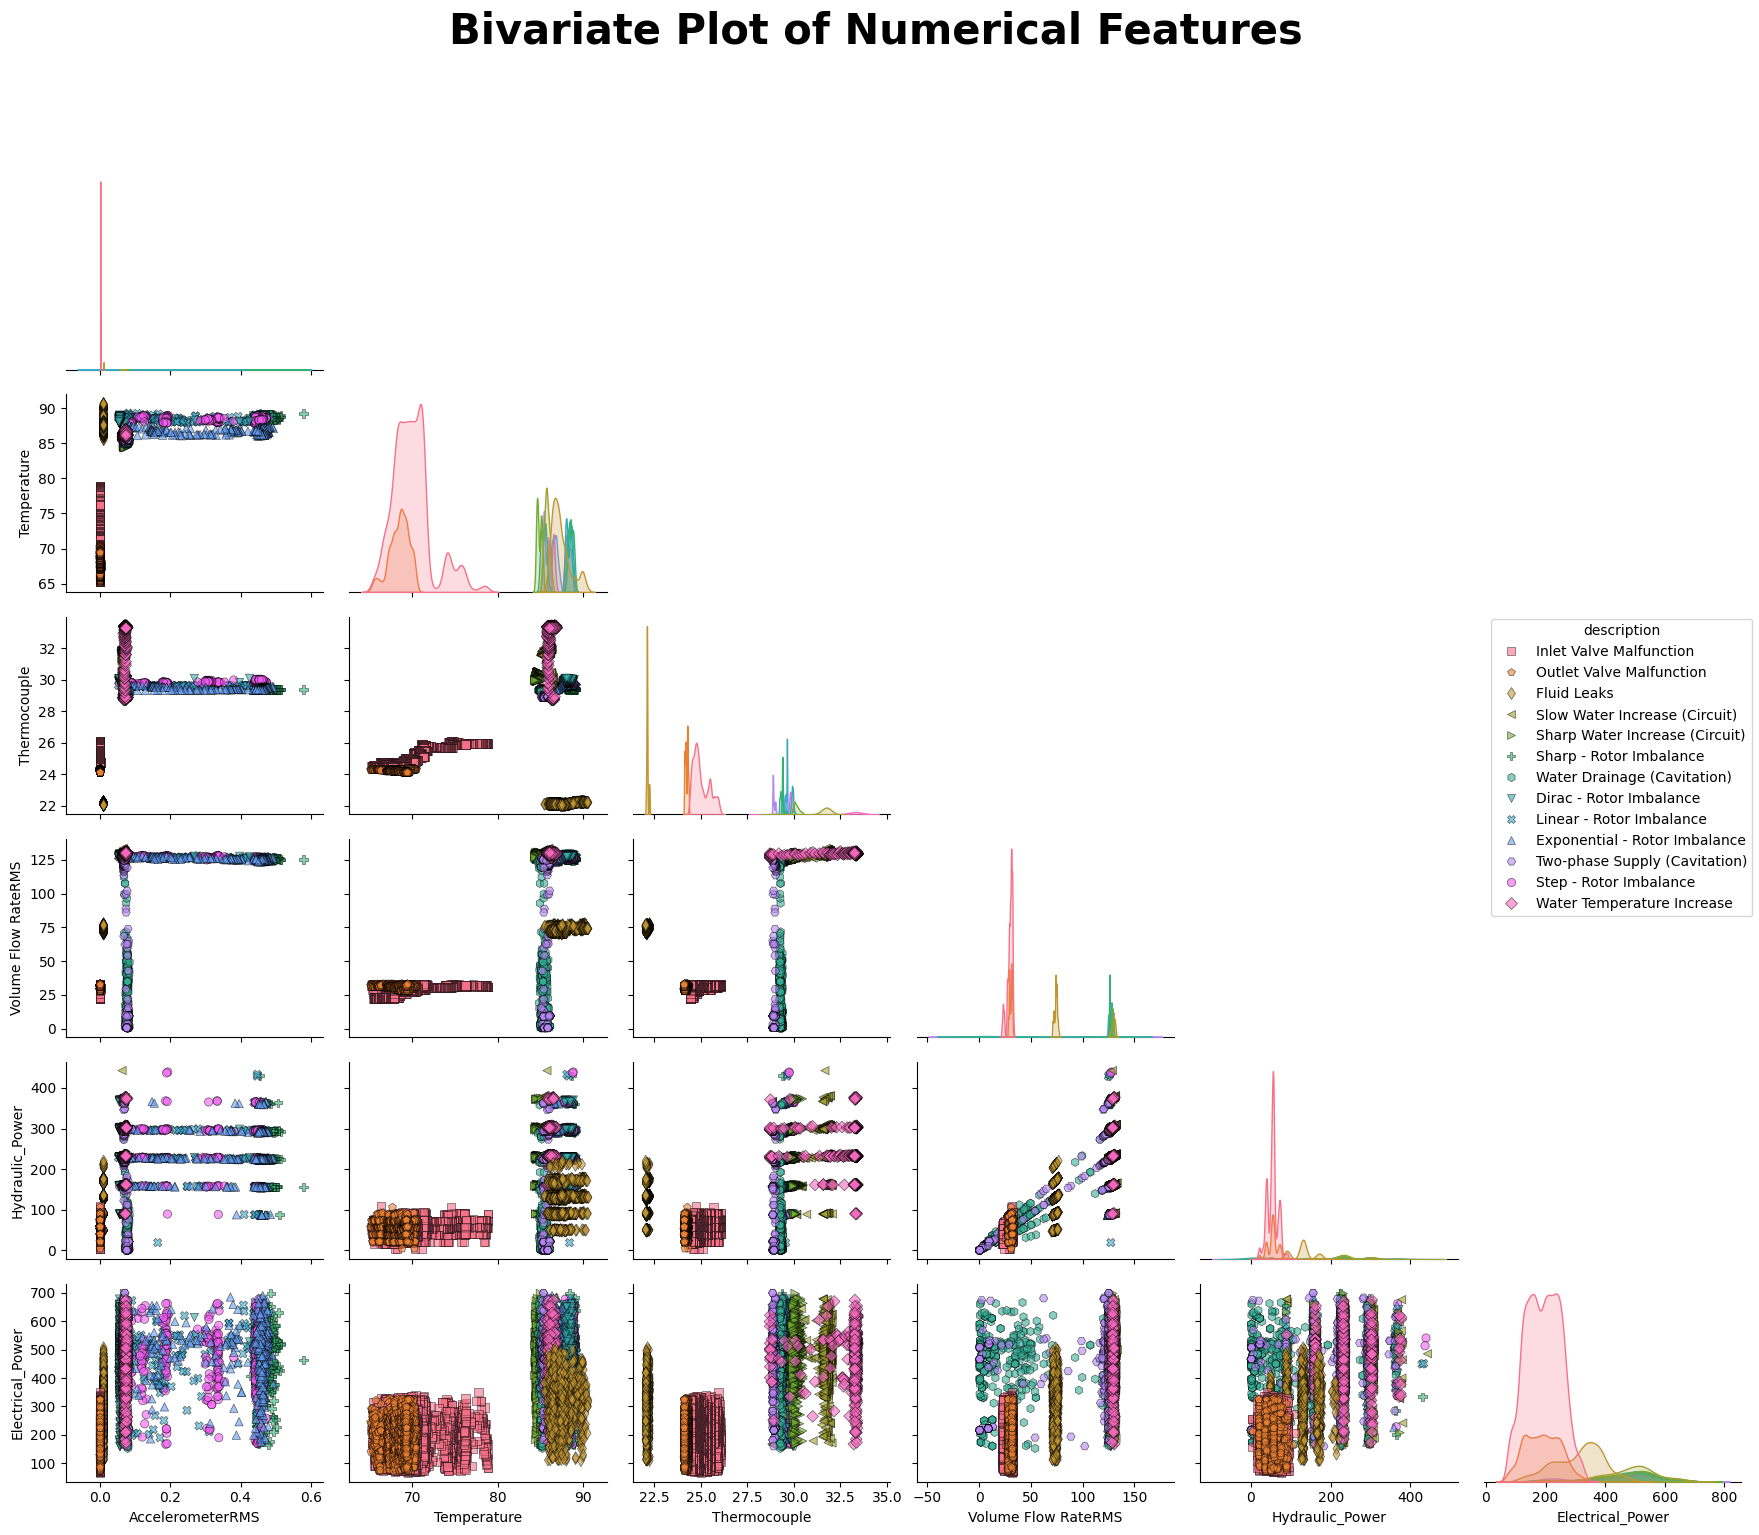

<Figure size 1200x1200 with 0 Axes>

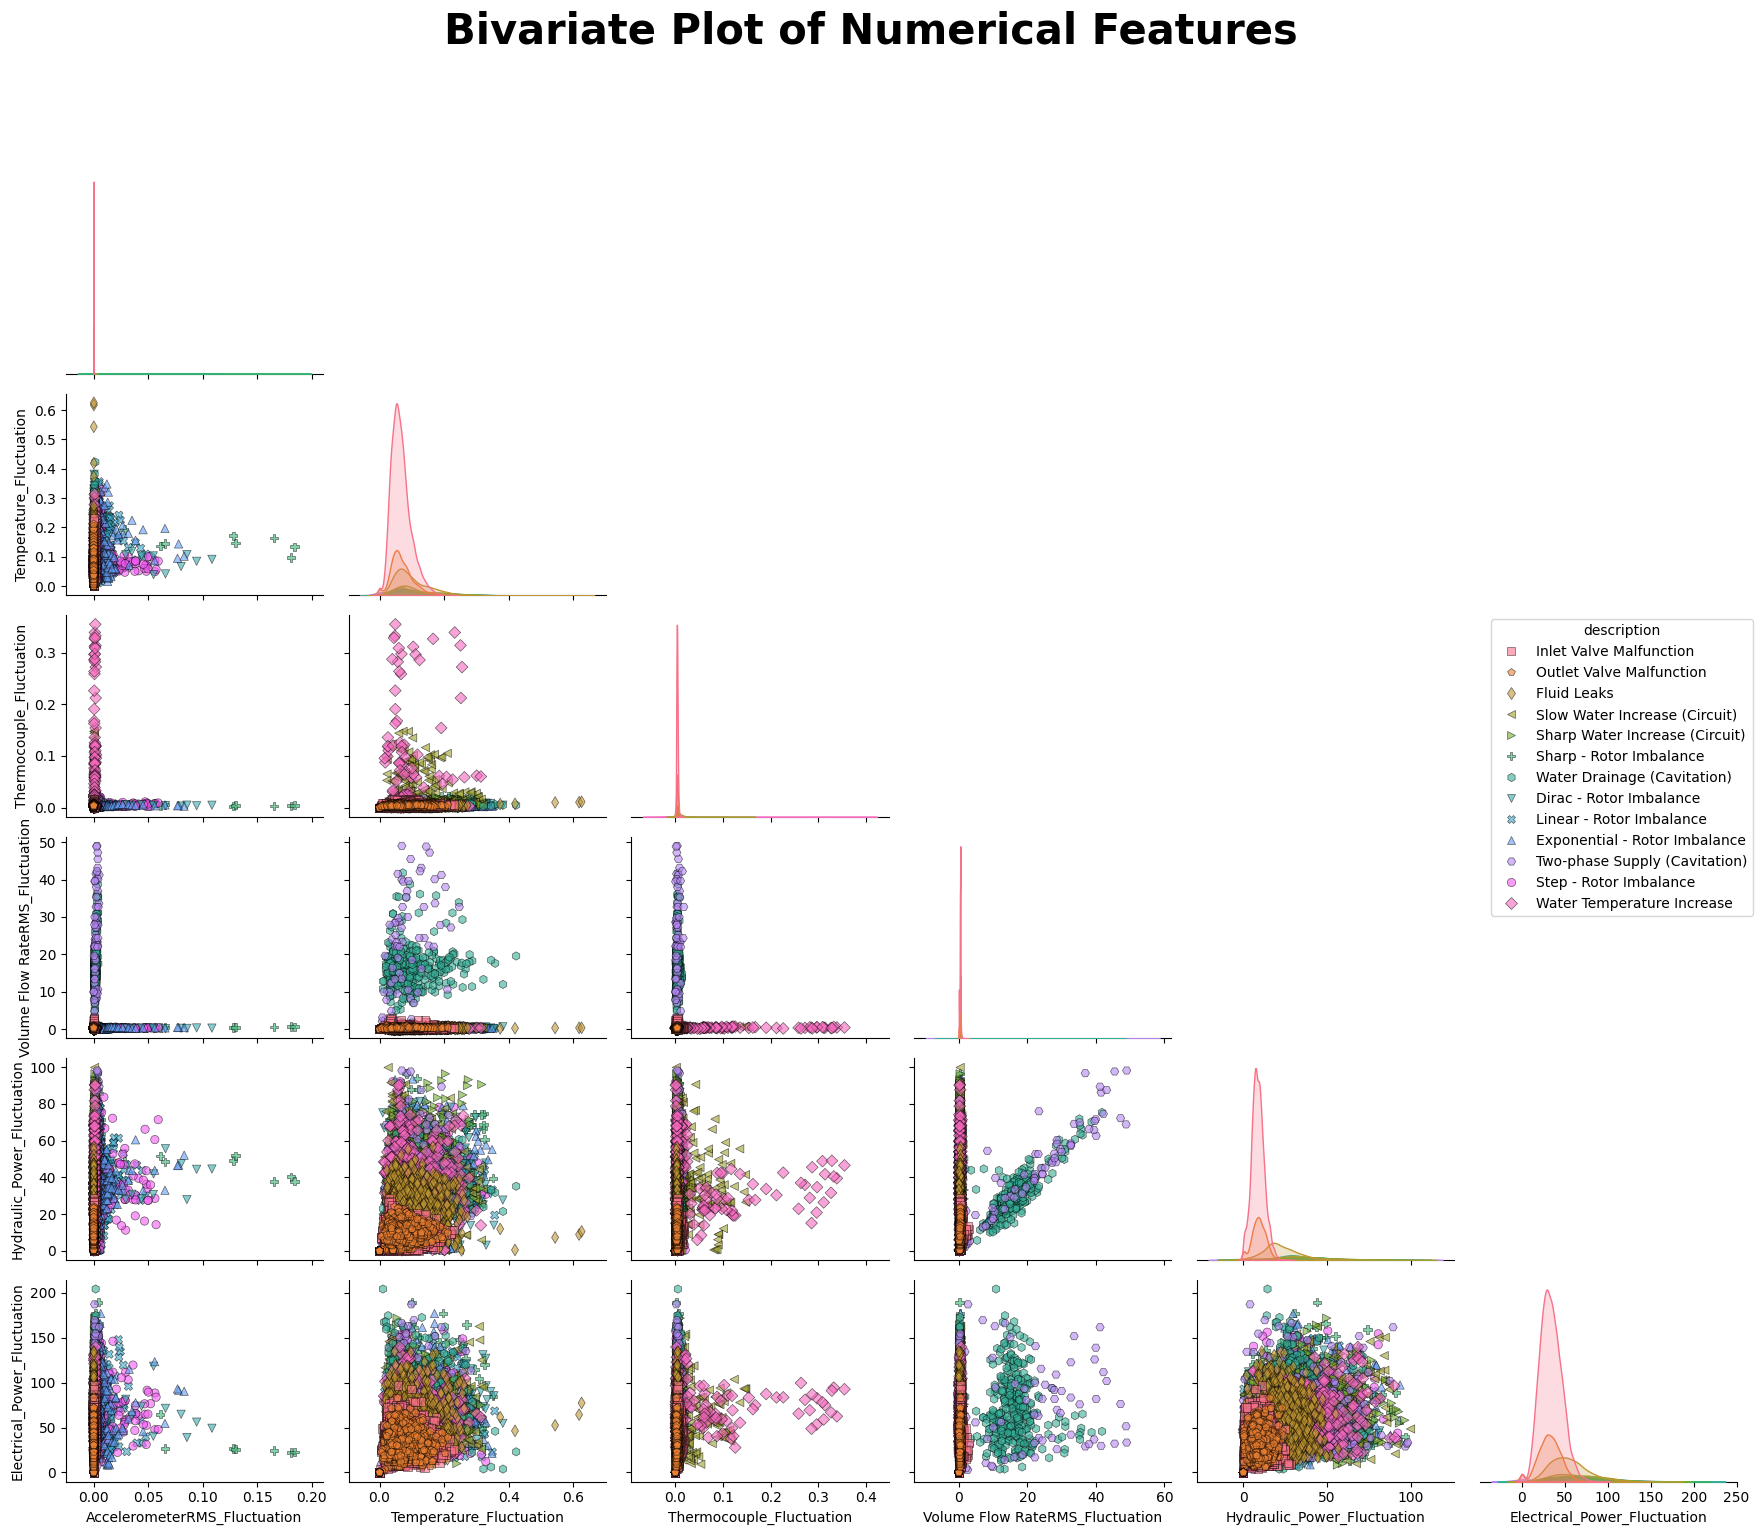

In [8]:
columns = [
            "AccelerometerRMS",
            "Temperature",
            "Thermocouple",
            "Volume Flow RateRMS",
            "Hydraulic_Power",
            "Electrical_Power",
]

fluctuation_columns = list()
for column in columns:
    fluctuation_columns.append(get_fluctuation_data(dataframe, column)) 

    tmp_dataframe = pd.concat([dataframe, dataframe_anomaly], axis=1)

# plot_pairplot(tmp_dataframe, fluctuation_columns, title="Bivariate Plot of Numerical Features")

plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], columns, title="Bivariate Plot of Numerical Features")
plot_pairplot(tmp_dataframe.iloc[np.where(tmp_dataframe.anomaly!=0.0)], fluctuation_columns, title="Bivariate Plot of Numerical Features")

In [9]:
dataframe.columns

Index(['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
       'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS',
       'Electrical_Resistence', 'Flow_Resistance', 'Temperature_EbyF',
       'AccelerometerRMS', 'Specific_Power', 'Accelerometer_Balance',
       'Temperature_Difference', 'Hydraulic_Power', 'Electrical_Power',
       'Actual_Efficiency', 'Vibration_Intensity_Ratio',
       'AccelerometerRMS_pu_Pressure', 'Engine_Temperature_pu_Power',
       'Efficiency_Temperature_Difference_Ratio',
       'AccelerometerRMS_Fluctuation', 'Temperature_Fluctuation',
       'Thermocouple_Fluctuation', 'Volume Flow RateRMS_Fluctuation',
       'Hydraulic_Power_Fluctuation', 'Electrical_Power_Fluctuation'],
      dtype='object')

In [10]:
dataframe.isnull().sum()

Accelerometer1RMS                          0
Accelerometer2RMS                          0
Current                                    0
Pressure                                   0
Temperature                                0
Thermocouple                               0
Voltage                                    0
Volume Flow RateRMS                        0
Electrical_Resistence                      0
Flow_Resistance                            0
Temperature_EbyF                           0
AccelerometerRMS                           0
Specific_Power                             0
Accelerometer_Balance                      0
Temperature_Difference                     0
Hydraulic_Power                            0
Electrical_Power                           0
Actual_Efficiency                          0
Vibration_Intensity_Ratio                  0
AccelerometerRMS_pu_Pressure               0
Engine_Temperature_pu_Power                0
Efficiency_Temperature_Difference_Ratio    0
Accelerome

In [11]:
dataframe.bfill(inplace=True)

In [12]:
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.710228,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695


In [13]:
dataframe.isnull().sum()

Accelerometer1RMS                          0
Accelerometer2RMS                          0
Current                                    0
Pressure                                   0
Temperature                                0
Thermocouple                               0
Voltage                                    0
Volume Flow RateRMS                        0
Electrical_Resistence                      0
Flow_Resistance                            0
Temperature_EbyF                           0
AccelerometerRMS                           0
Specific_Power                             0
Accelerometer_Balance                      0
Temperature_Difference                     0
Hydraulic_Power                            0
Electrical_Power                           0
Actual_Efficiency                          0
Vibration_Intensity_Ratio                  0
AccelerometerRMS_pu_Pressure               0
Engine_Temperature_pu_Power                0
Efficiency_Temperature_Difference_Ratio    0
Accelerome

In [14]:
tmp_dataframe = pd.concat([dataframe, dataframe_anomaly], axis=1)
tmp_dataframe.to_csv("../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv")